# 03 — Testes de hipótese

Cada hipótese: H0/H1, teste, **tamanho de efeito + IC95 + p**, correção de **Holm** para
as 6 hipóteses e **significância prática** (efeito mínimo relevante definido antes).
A lógica está em `src/analysis/hypotheses.py` (testada).

Desenho dos testes de painel (H1, H3, H4, H6): efeitos fixos de **país** (só variação dentro
do país) e de **ano** (choques globais), controle log(PIB/capita), SE cluster por país; a
variável de interesse é padronizada (efeito por +1 DP).

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from config import settings
from src.utils.io import load_parquet
from src.analysis import eda
from src.viz import style

style.use_matplotlib()
pd.set_option("display.max_columns", 40, "display.width", 160, "display.precision", 2)
abt = load_parquet("gold", "abt_country_year")
print(f"ABT: {abt.shape[0]:,} linhas x {abt.shape[1]} colunas | "
      f"{abt.country_id.nunique()} paises | {abt.year.min()}-{abt.year.max()}")

ABT: 7,378 linhas x 37 colunas | 217 paises | 1990-2023


In [2]:
from src.analysis.hypotheses import run_all, to_frame
hs = run_all(abt, n_boot=199)
tbl = to_frame(hs)
tbl

,id,hipotese,efeito,unidade,ic95,p,p_holm,n,min_relevante,veredito
0,H1,Densidade de medicos => expectativa de vida (l...,-1.09,anos por +1 DP de medicos/1000,"[-1.61, -0.57]",3.64e-05,1.09e-04,3824,0.5,Rejeita H0 - efeito na direcao OPOSTA a H1
1,H2,Saneamento basico > 80% => mortalidade <5 menor,-43.10,mortes/1000 nascidos (dif. de medianas),"[-49.00, -35.80]",1.31e-25,7.88e-25,186,5.0,Rejeita H0 - efeito relevante
2,H3,+1 DP no gasto publico em saude => delta na ex...,-0.43,anos por +1 DP de gasto publico (% PIB),"[-0.84, -0.03]",3.73e-02,7.47e-02,4512,0.5,Inconclusiva - sensivel a especificacao (fe_pa...
3,H4,Urbanizacao associada a mortalidade <5 menor,-27.61,mortes/1000 por +1 DP de urbanizacao,"[-39.21, -16.01]",3.13e-06,1.25e-05,6471,5.0,Rejeita H0 - efeito relevante
4,H5,"Apos cruzar o limiar UHC, a expectativa de vid...",0.07,anos (ATT medio pos-adocao),"[-0.50, 0.61]",7.84e-01,7.84e-01,99,0.5,Nao rejeita H0
5,H6,Vacinacao contra sarampo associada a mortalida...,-10.35,mortes/1000 por +1 DP de cobertura vacinal,"[-13.92, -6.77]",1.44e-08,7.21e-08,6334,5.0,Rejeita H0 - efeito relevante


## Robustez: variação entre países vs dentro do país

In [3]:
rows = []
for h in hs:
    rb = h.extra.get("robustness")
    if not rb: continue
    fmt = lambda v: f"{v['coef']:+.2f}{'*' if v['p'] < 0.05 else ''}"
    rows.append({"id": h.id, "FE país+ano (principal)": f"{h.effect:+.2f}",
                 "FE sem Europa/Ásia Central": fmt(rb["fe_sem_europa_asia_central"]),
                 "FE país, sem FE de ano": fmt(rb["fe_pais_sem_fe_ano"]),
                 "pooled (entre+dentro)": fmt(rb["pooled_between_within"])})
print("* = p < 0.05. As duas primeiras colunas alternativas medem o mesmo estimando (dentro do país):")
print("  se uma delas inverter o sinal com significância, o veredito vira 'Inconclusiva'.")
pd.DataFrame(rows).set_index("id")

* = p < 0.05. As duas primeiras colunas alternativas medem o mesmo estimando (dentro do país):
  se uma delas inverter o sinal com significância, o veredito vira 'Inconclusiva'.


,FE país+ano (principal),FE sem Europa/Ásia Central,"FE país, sem FE de ano",pooled (entre+dentro)
id,,,,
H1,-1.09,-1.50*,+0.30,+1.76*
H3,-0.43,-0.39,+0.46*,+0.54
H4,-27.61,-24.97*,-38.45*,-4.35
H6,-10.34,-11.68*,-12.12*,-21.11*


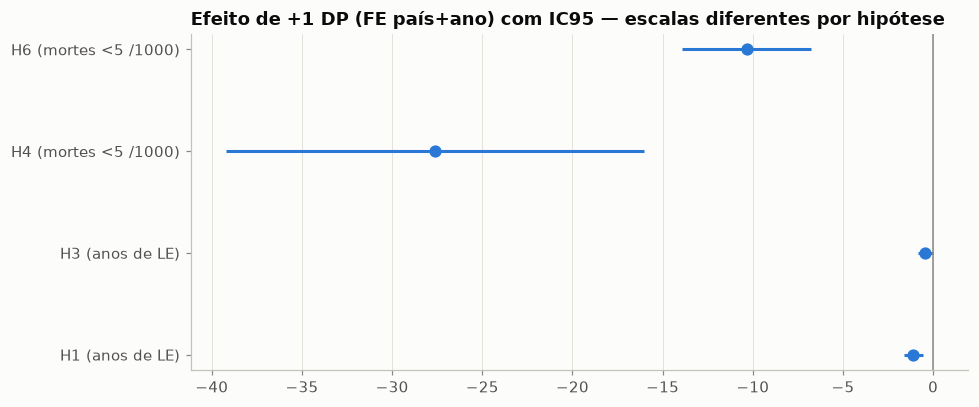

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.8))
labels, eff, lo, hi = [], [], [], []
for h in hs:
    if h.id in ("H1", "H3"):
        labels.append(f"{h.id} (anos de LE)")
    elif h.id in ("H4", "H6"):
        labels.append(f"{h.id} (mortes <5 /1000)")
    else:
        continue
    eff.append(h.effect); lo.append(h.ci95[0]); hi.append(h.ci95[1])
y = np.arange(len(labels))
ax.errorbar(eff, y, xerr=[np.array(eff) - lo, np.array(hi) - eff], fmt="o", color=style.HIGHLIGHT,
            ecolor=style.HIGHLIGHT, elinewidth=2, capsize=0, markersize=7)
ax.axvline(0, color=style.INK["muted"], lw=1)
ax.set_yticks(y, labels); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Efeito de +1 DP (FE país+ano) com IC95 — escalas diferentes por hipótese")
plt.tight_layout(); plt.show()

## H2 em detalhe e H5 (event study)

In [5]:
h2 = next(h for h in hs if h.id == "H2")
print(json.dumps({k: v for k, v in h2.extra.items()}, indent=1, default=float))

{
 "n_high": 119,
 "n_low": 67,
 "median_high": 8.5,
 "median_low": 51.6,
 "cliffs_delta": -0.9249968644174088,
 "adjusted_gdp": {
  "coef": -25.087708054404864,
  "ci95": [
   -32.541050366574865,
   -17.634365742234866
  ],
  "p": 4.190657535926206e-11
 }
}


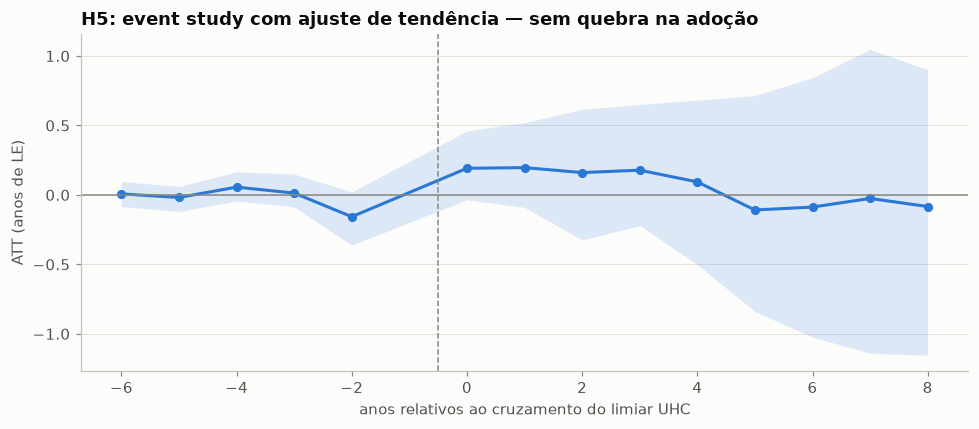

In [6]:
h5 = next(h for h in hs if h.id == "H5")
ev = pd.DataFrame(h5.extra["event_study"])
fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(ev.e, [c[0] for c in ev.ci95], [c[1] for c in ev.ci95], color=style.HIGHLIGHT, alpha=0.15, lw=0)
ax.plot(ev.e, ev.att, "o-", color=style.HIGHLIGHT)
ax.axhline(0, color=style.INK["muted"], lw=1); ax.axvline(-0.5, color=style.INK["muted"], lw=1, ls="--")
ax.set_xlabel("anos relativos ao cruzamento do limiar UHC"); ax.set_ylabel("ATT (anos de LE)")
ax.set_title("H5: event study com ajuste de tendência — sem quebra na adoção")
plt.tight_layout(); plt.show()

In [7]:
for h in hs:
    print(f"{h.id}: {h.verdict}  (efeito {h.effect:+.2f} {h.effect_unit}; p_holm={h.p_holm:.2g})")

H1: Rejeita H0 - efeito na direcao OPOSTA a H1  (efeito -1.09 anos por +1 DP de medicos/1000; p_holm=0.00011)
H2: Rejeita H0 - efeito relevante  (efeito -43.10 mortes/1000 nascidos (dif. de medianas); p_holm=7.9e-25)
H3: Inconclusiva - sensivel a especificacao (fe_pais_sem_fe_ano inverte o sinal)  (efeito -0.43 anos por +1 DP de gasto publico (% PIB); p_holm=0.075)
H4: Rejeita H0 - efeito relevante  (efeito -27.61 mortes/1000 por +1 DP de urbanizacao; p_holm=1.3e-05)
H5: Nao rejeita H0  (efeito +0.07 anos (ATT medio pos-adocao); p_holm=0.78)
H6: Rejeita H0 - efeito relevante  (efeito -10.34 mortes/1000 por +1 DP de cobertura vacinal; p_holm=7.2e-08)


## Leitura consolidada

- **H2, H4, H6 — confirmadas e relevantes.** Saneamento > 80% vem com mortalidade <5 **~43/1000
  menor** (diferença de medianas; Cliff's δ ≈ −0.92). Ajustando por log PIB o efeito cai para
  ~25/1000, mas persiste (ver `adjusted_gdp`) — parte da diferença é desenvolvimento. Urbanização
  e vacinação contra sarampo têm associação **dentro do país** com menor mortalidade <5, robusta à
  exclusão de Europa/Ásia Central.
- **H1 — direção oposta dentro do país.** Entre países, mais médicos ↔ maior LE (pooled positivo).
  Mas, dentro de um mesmo país e descontados choques globais e o PIB, aumentos de densidade médica
  **não** vêm com ganhos de LE (coeficiente negativo, mesmo sem a transição pós-soviética). A
  associação clássica é **entre países** (desenvolvimento), não um efeito marginal de mais médicos.
  (Sem FE de ano o sinal fica positivo, mas não significativo — por isso o veredito se mantém.)
- **H3 — inconclusiva (sensível à especificação).** Com FE de ano, o gasto público (% PIB) tem
  coeficiente negativo e não significativo após Holm; sem FE de ano ele fica **positivo e
  significativo**. A associação positiva vem de tendências globais comuns (LE e gasto sobem juntos
  no mundo todo), não de variação específica do país.
- **H5 — não rejeitada.** O DiD ingênuo dá efeito *negativo*, mas o event study mostra uma
  tendência diferencial **pré-existente** (convergência dos países mais pobres). Com ajuste de
  tendência, o ATT é ~0 (IC inclui 0): cruzar o limiar do proxy não acelera a LE de forma
  detectável. Detalhes no notebook 05.